## Movie Reccomendation Sysytem

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
movies = pd.read_csv('movies.csv')
credits = pd.read_csv('credits.csv')

In [4]:
movies= movies.merge(credits, on='title')

In [5]:
movies.head()

,movie_id,title,cast,crew,budget,genres,homepage,id,keywords,original_language,...,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,vote_average,vote_count
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,...,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,7.2,11800
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,...,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",6.9,4500
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,...,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,6.3,4466
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,...,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,7.6,9106
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,...,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",6.1,2124


In [8]:
movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]
movies.dropna(inplace=True)

In [9]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4806 entries, 0 to 4808
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4806 non-null   int64 
 1   title     4806 non-null   object
 2   overview  4806 non-null   object
 3   genres    4806 non-null   object
 4   keywords  4806 non-null   object
 5   cast      4806 non-null   object
 6   crew      4806 non-null   object
dtypes: int64(1), object(6)
memory usage: 300.4+ KB


In [10]:
movies.isnull().sum()

movie_id    0
title       0
overview    0
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [11]:
print("Total Movies:", movies.shape[0])

Total Movies: 4806


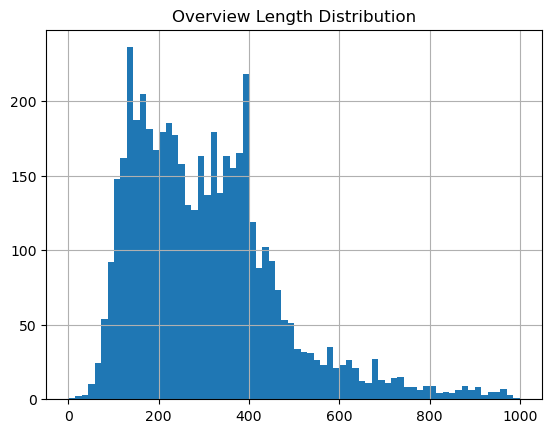

In [16]:
movies['overview'].apply(len).hist(bins=70)
plt.title('Overview Length Distribution')
plt.show()

## Feature Engineering

Convert JSON to List

In [17]:
import ast 
def convert(text):
    L=[]
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return L

movies['genres'] = movies['genres'].apply(convert)
movies['keywords']= movies['keywords'].apply(convert)

Extract Top 3 Cast Members

In [18]:
def convert_cast(text):
    L=[]
    counter = 0
    for i in ast.literal_eval(text):
        if counter!=3:
            L.append(i['name'])
            counter +=1
        else:
            break
        return L

movies['cast']= movies['cast'].apply(convert_cast)

Extract Director from Crew

In [20]:
def fetch_director(text):
    L=[]
    for i in ast.literal_eval(text):
        if['job'] == 'Director':
            L.append(i['name'])
        return L

movies['crew']= movies['crew'].apply(fetch_director)

Remove Spaces (important for vectorization)

In [22]:
def collapse(L):
    if isinstance(L, list):
        return [i.replace(" ", "") for i in L]
    return []

In [32]:
movies['overview'] = movies['overview'].apply(
    lambda x: x.split() if isinstance(x, str) else x
)
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] +movies['cast'] + movies['crew']

In [36]:
df= movies[['movie_id','title','tags']]
df['tags'] = df['tags'].apply(
    lambda x: " ".join(x) if isinstance(x, list) else "")

In [43]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(df['tags']).toarray()

In [44]:
similarity = cosine_similarity(vectors)

In [45]:
def recommend(movie):
    movie_index = df[df['title'] == movie].index[0]
    distances = similarity[movie_index]
    
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    for i in movies_list:
        print(df.iloc[i[0]].title)

## Test Model

In [46]:
recommend('Avatar')

Titan A.E.
Independence Day
Small Soldiers
Ender's Game
Aliens vs Predator: Requiem


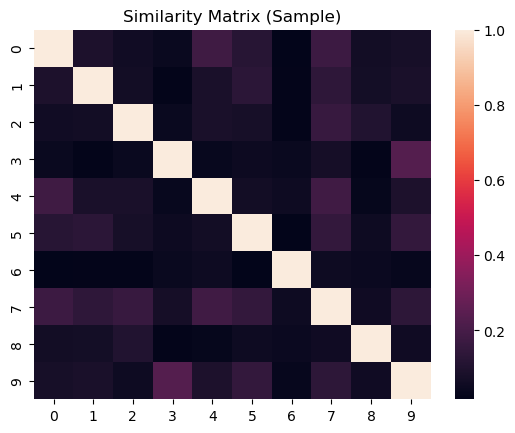

In [47]:
sns.heatmap(similarity[:10, :10])
plt.title("Similarity Matrix (Sample)")
plt.show()

In [49]:
import pickle

pickle.dump(df, open('movies.pkl','wb'))
pickle.dump(similarity, open('similarity.pkl','wb'))